# Analisis Perbandingan Akurasi Algoritma *Item-Based Collaborative Filtering* Statis dan *Time-Aware* pada Sistem Rekomendasi Playlist Musik

**Dataset:** Last.fm (Kaggle) &nbsp;|&nbsp; **Environment:** Google Colab

---

## Penjelasan Singkat

Notebook ini membandingkan dua varian algoritma *Item-Based Collaborative Filtering* (IBCF) untuk sistem rekomendasi playlist musik:

1. **IBCF Statis** — seluruh riwayat mendengarkan diperlakukan sama, tanpa memperhatikan waktu interaksi.
2. **IBCF Time-Aware** — interaksi terbaru diberi bobot lebih besar melalui *time decay* (peluruhan waktu), dengan asumsi preferensi musik berubah seiring waktu.

**Tujuan penelitian:** mengukur apakah penyertaan dimensi waktu meningkatkan akurasi rekomendasi.

**Metrik evaluasi:** Precision@10, Recall@10, MAP@10, dan NDCG@10, dengan skema *leave-last-out*.

**Catatan teknis penting:** seluruh perhitungan kemiripan menggunakan matriks sparse (CSR), bukan *dense pivot table*. Ini mencegah notebook memakan memori berlebihan (penyebab umum *kernel restart* pada dataset Last.fm yang besar).

---

### Struktur Notebook
| Bagian | Judul |
|:------:|-------|
| 1 | Persiapan Environment |
| 2 | Memuat Dataset (Google Drive) |
| 3 | Exploratory Data Analysis |
| 4 | Data Preprocessing |
| 5 | Data Filtering |
| 6 | Data Transformation (Sparse Matrix) |
| 7 | Model IBCF Statis |
| 8 | Model IBCF Time-Aware |
| 9 | Evaluasi (Precision/Recall/MAP/NDCG) |
| 10 | Visualisasi |
| 11 | Kesimpulan |
| Lampiran | Output Playlist + Genre |


# 1. Persiapan Environment

### Tujuan
Menyiapkan dan memverifikasi seluruh *library* yang dibutuhkan.

### Catatan
Semua *library* di bawah sudah tersedia secara bawaan di Google Colab, sehingga tidak diperlukan instalasi tambahan. Peneliti menggunakan `scipy.sparse` dan `sklearn` untuk komputasi kemiripan yang efisien pada data berdimensi besar.


In [1]:
# --- Library standar ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Library untuk matriks sparse & kemiripan (kunci efisiensi memori) ---
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

import os
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Pengaturan tampilan
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')

print("Environment siap.")
print("Versi pandas :", pd.__version__)
print("Versi numpy  :", np.__version__)

Environment siap.
Versi pandas : 2.2.2
Versi numpy  : 2.0.2


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Memuat Dataset

### Tujuan
Memuat dataset Last.fm dari penyimpanan ke dalam *environment* Colab.

### Alur
```
Google Drive  ─►  /content  ─►  DataFrame (df)
```


In [3]:
# >>> SESUAIKAN PATH FILE DI SINI <<<
PATH_DATASET = '/content/drive/My Drive/userid-timestamp-artid-artname-traid-traname.tsv'

print("Path dataset diset ke:")
print(" ", PATH_DATASET)


Path dataset diset ke:
  /content/drive/My Drive/userid-timestamp-artid-artname-traid-traname.tsv


In [4]:
# ============================================================
# Membaca Dataset LastFM menjadi DataFrame (df_raw)
# ============================================================
# Dataset yang digunakan:
# userid-timestamp-artid-artname-traid-traname.tsv
#
# File menggunakan separator TAB (\t) tanpa header sehingga
# nama kolom ditentukan secara manual agar lebih jelas dan
# proses pembacaan data lebih efisien.
# ============================================================

column_names = [
    "user_id",
    "timestamp",
    "artist_id",
    "artist_name",
    "track_id",
    "track_name"
]

dtype_dict = {
    "user_id": "string",
    "timestamp": "string",
    "artist_id": "string",
    "artist_name": "string",
    "track_id": "string",
    "track_name": "string"
}

df_raw = pd.read_csv(
    PATH_DATASET,
    sep="\t",
    names=column_names,
    header=None,
    dtype=dtype_dict,
    engine="c",
    encoding="utf-8",
    low_memory=False,
    on_bad_lines="skip"
)

print("Ukuran data mentah :", df_raw.shape)

display(df_raw.head())

Ukuran data mentah : (19098853, 6)


,user_id,timestamp,artist_id,artist_name,track_id,track_name
0,user_000001,2009-05-04T23:08:57Z,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,<NA>,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,user_000001,2009-05-04T13:54:10Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,<NA>,Composition 0919 (Live_2009_4_15)
2,user_000001,2009-05-04T13:52:04Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,<NA>,Mc2 (Live_2009_4_15)
3,user_000001,2009-05-04T13:42:52Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,<NA>,Hibari (Live_2009_4_15)
4,user_000001,2009-05-04T13:42:11Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,<NA>,Mc1 (Live_2009_4_15)


# 3. Exploratory Data Analysis (EDA)

### Tujuan
Memahami karakteristik dataset secara ringkas sebelum dilakukan pembersihan: jumlah baris, kolom yang tersedia, dan sebaran data.

### Output yang diharapkan
- Identifikasi kolom *user*, *item (lagu/artis)*, dan *timestamp*.
- Gambaran awal popularitas item dan aktivitas user.


In [5]:
# ============================================================
# Penentuan Kolom Dataset
# ============================================================
# Dataset LastFM 1K memiliki struktur kolom yang telah diketahui,
# sehingga tidak diperlukan proses deteksi kolom secara otomatis.
#
# Pada penelitian ini:
# - User direpresentasikan oleh user_id.
# - Item direpresentasikan oleh track_name karena memiliki nilai
#   missing yang sangat sedikit dibandingkan track_id.
# - Timestamp digunakan pada implementasi Time-Aware IBCF.
# - track_id dan artist_id tetap dipertahankan sebagai informasi
#   referensi apabila diperlukan pada tahap analisis maupun
#   visualisasi hasil rekomendasi.
# ============================================================

# Kolom utama
user_col = "user_id"
time_col = "timestamp"
item_col = "track_name"

# Kolom referensi
track_id_col = "track_id"
artist_col = "artist_id"
artist_name_col = "artist_name"

print("=" * 55)
print("INFORMASI KOLOM DATASET")
print("=" * 55)

print(f"User ID          : {user_col}")
print(f"Timestamp        : {time_col}")
print(f"Item             : {item_col}")
print(f"Track ID         : {track_id_col}")
print(f"Artist ID        : {artist_col}")
print(f"Artist Name      : {artist_name_col}")

INFORMASI KOLOM DATASET
User ID          : user_id
Timestamp        : timestamp
Item             : track_name
Track ID         : track_id
Artist ID        : artist_id
Artist Name      : artist_name


In [6]:
# ============================================================
# Ringkasan Dataset Mentah
# ============================================================

print("=" * 60)
print("RINGKASAN DATASET MENTAH")
print("=" * 60)

print(f"Jumlah baris             : {len(df_raw):,}")
print(f"Jumlah kolom             : {df_raw.shape[1]}")
print(f"Jumlah user unik         : {df_raw[user_col].nunique():,}")
print(f"Jumlah artist unik       : {df_raw[artist_col].nunique():,}")
print(f"Jumlah lagu unik         : {df_raw[item_col].nunique():,}")

print("\nJumlah Missing Value")
print(df_raw.isna().sum())

RINGKASAN DATASET MENTAH
Jumlah baris             : 19,098,853
Jumlah kolom             : 6
Jumlah user unik         : 992
Jumlah artist unik       : 107,295
Jumlah lagu unik         : 1,083,470

Jumlah Missing Value
user_id              0
timestamp            0
artist_id       600848
artist_name          0
track_id       2162719
track_name         210
dtype: int64


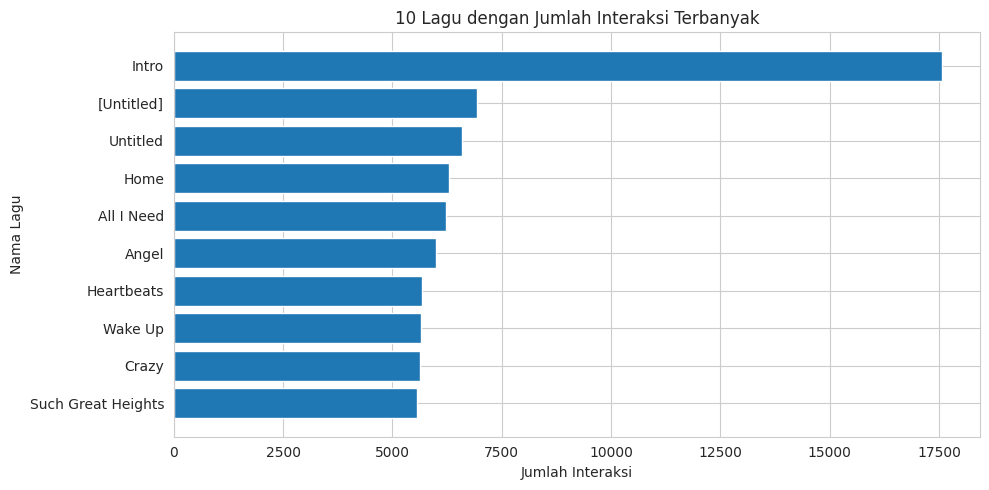

In [7]:
# ============================================================
# Visualisasi 10 Lagu dengan Jumlah Interaksi Terbanyak
# ============================================================

top_track = (
    df_raw[item_col]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_track.index,
    top_track.values
)

plt.gca().invert_yaxis()

plt.title("10 Lagu dengan Jumlah Interaksi Terbanyak")
plt.xlabel("Jumlah Interaksi")
plt.ylabel("Nama Lagu")

plt.tight_layout()

plt.show()

Statistik Aktivitas User
count           992.0
mean     19252.876008
std      23153.905248
min               2.0
25%           3774.25
50%           11547.5
75%          25672.25
max          183103.0
Name: count, dtype: Float64


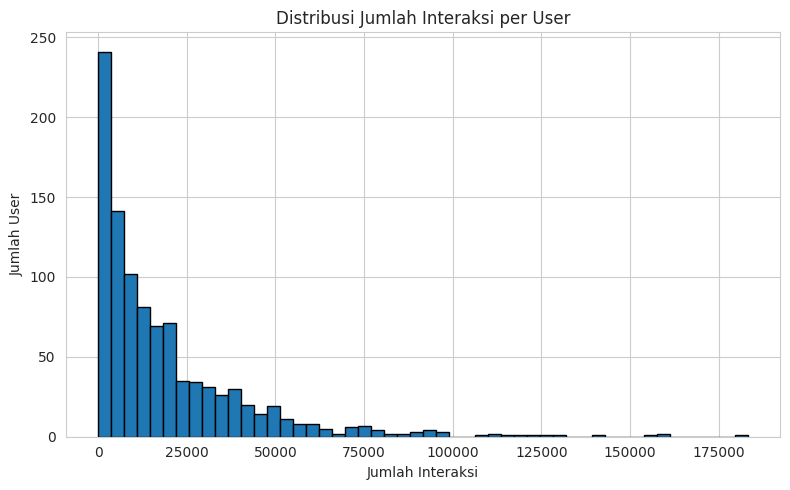

In [8]:
# ============================================================
# Distribusi Jumlah Interaksi per User
# ============================================================

user_activity = df_raw[user_col].value_counts()

print("Statistik Aktivitas User")
print(user_activity.describe())

plt.figure(figsize=(8,5))

plt.hist(user_activity, bins=50, edgecolor="black")

plt.title("Distribusi Jumlah Interaksi per User")
plt.xlabel("Jumlah Interaksi")
plt.ylabel("Jumlah User")

plt.tight_layout()

plt.show()

Statistik Popularitas Lagu
count    1083470.0
mean     17.627293
std      84.421429
min            1.0
25%            1.0
50%            3.0
75%            9.0
max        17561.0
Name: count, dtype: Float64


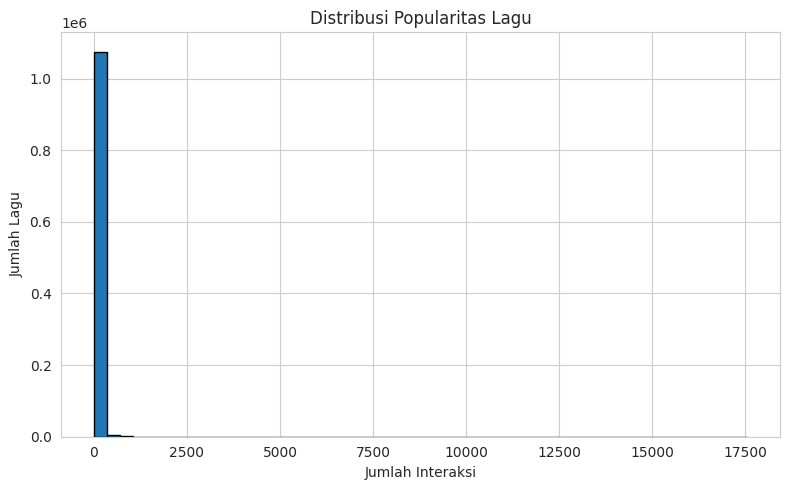

In [9]:
# ============================================================
# Distribusi Popularitas Lagu
# ============================================================

track_popularity = df_raw[item_col].value_counts()

print("Statistik Popularitas Lagu")
print(track_popularity.describe())

plt.figure(figsize=(8,5))

plt.hist(track_popularity, bins=50, edgecolor="black")

plt.title("Distribusi Popularitas Lagu")
plt.xlabel("Jumlah Interaksi")
plt.ylabel("Jumlah Lagu")

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# Informasi Penggunaan Memori Dataset
# ============================================================

print(df_raw.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19098853 entries, 0 to 19098852
Data columns (total 6 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      string
 1   timestamp    string
 2   artist_id    string
 3   artist_name  string
 4   track_id     string
 5   track_name   string
dtypes: string(6)
memory usage: 7.5 GB
None


# 4. Data Preprocessing

### Tujuan
Membersihkan dataset agar siap digunakan pada proses pembentukan *user-item matrix*.

### Output
- Dataset bersih dengan kolom standar: `user`, `item`, `timestamp`.
- *Timestamp* valid (terkonversi ke tipe `datetime`).
- *Missing value* dan baris kosong terhapus.


In [11]:
# ============================================================
# Data Preprocessing
# ============================================================
# Tahap ini bertujuan untuk:
# 1. Menyusun dataset ke dalam format standar.
# 2. Membentuk representasi item yang unik.
# 3. Mengonversi timestamp ke format datetime.
# 4. Menghapus missing value dan data duplikat.
# ============================================================

# -----------------------------
# Menyusun DataFrame standar
# -----------------------------
df = pd.DataFrame()

# User
df["user"] = df_raw[user_col].astype("string")

# ============================================================
# Membentuk representasi item
# ============================================================
# Dataset LastFM memiliki banyak nilai kosong pada track_id,
# sehingga penelitian ini menggunakan kombinasi artist_name
# dan track_name sebagai identitas item.
#
# Pendekatan ini bertujuan untuk:
# 1. Meminimalkan kehilangan data akibat missing value.
# 2. Menghindari lagu berbeda dengan judul sama dianggap
#    sebagai item yang identik.
# ============================================================

df["item"] = (
    df_raw[artist_name_col].fillna("Unknown Artist").astype("string")
    + " - "
    + df_raw[item_col].fillna("Unknown Track").astype("string")
)

# Timestamp
df["timestamp"] = pd.to_datetime(
    df_raw[time_col],
    errors="coerce",
    utc=True
)

# ============================================================
# Menghapus Missing Value
# ============================================================

sebelum = len(df)

df = df.dropna(subset=["user", "item", "timestamp"])

df = df[df["item"].str.strip() != ""]

# ============================================================
# Menghapus Data Duplikat
# ============================================================

df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# ============================================================
# Menetapkan kolom yang digunakan pada tahap pemodelan
# ============================================================

user_col = "user"
item_col = "item"
time_col = "timestamp"

# ============================================================
# Ringkasan Hasil Preprocessing
# ============================================================

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

print(f"Jumlah data sebelum preprocessing : {sebelum:,}")
print(f"Jumlah data sesudah preprocessing : {len(df):,}")
print(f"Jumlah data yang dihapus          : {sebelum-len(df):,}")

print(f"\nJumlah user unik                 : {df[user_col].nunique():,}")
print(f"Jumlah item unik                 : {df[item_col].nunique():,}")

print("\nRentang waktu dataset")
print(f"Awal  : {df[time_col].min()}")
print(f"Akhir : {df[time_col].max()}")

display(df.head())

DATA PREPROCESSING
Jumlah data sebelum preprocessing : 19,098,853
Jumlah data sesudah preprocessing : 19,098,851
Jumlah data yang dihapus          : 2

Jumlah user unik                 : 992
Jumlah item unik                 : 1,498,707

Rentang waktu dataset
Awal  : 2005-02-14 00:00:07+00:00
Akhir : 2013-09-29 18:32:04+00:00


,user,item,timestamp
0,user_000001,Deep Dish - Fuck Me Im Famous (Pacha Ibiza)-09...,2009-05-04 23:08:57+00:00
1,user_000001,坂本龍一 - Composition 0919 (Live_2009_4_15),2009-05-04 13:54:10+00:00
2,user_000001,坂本龍一 - Mc2 (Live_2009_4_15),2009-05-04 13:52:04+00:00
3,user_000001,坂本龍一 - Hibari (Live_2009_4_15),2009-05-04 13:42:52+00:00
4,user_000001,坂本龍一 - Mc1 (Live_2009_4_15),2009-05-04 13:42:11+00:00


In [12]:
# ============================================================
# Verifikasi Hasil Preprocessing
# ============================================================
# Memastikan dataset telah siap digunakan pada tahap filtering.
# ============================================================

print("=" * 60)
print("VERIFIKASI HASIL PREPROCESSING")
print("=" * 60)

print(f"Jumlah missing value :\n")
print(df.isna().sum())

print("\nJumlah data duplikat :", df.duplicated().sum())

print("\nTipe data:")
print(df.dtypes)

print("\nUkuran DataFrame :", df.shape)

VERIFIKASI HASIL PREPROCESSING
Jumlah missing value :

user         0
item         0
timestamp    0
dtype: int64

Jumlah data duplikat : 0

Tipe data:
user              string[python]
item              string[python]
timestamp    datetime64[ns, UTC]
dtype: object

Ukuran DataFrame : (19098851, 3)


# 5. Data Filtering

### Tujuan
Menyaring *user* dan *item* yang interaksinya terlalu sedikit.

### Justifikasi Akademik
Pada *Collaborative Filtering*, item/user dengan interaksi sangat sedikit menimbulkan masalah sparsity dan cold-start sehingga pola kemiripan menjadi tidak andal. Pemberian ambang minimum interaksi adalah praktik baku pada literatur sistem rekomendasi karena:
1. **Mengurangi sparsity** — matriks menjadi lebih padat dan kemiripan lebih bermakna.
2. **Meningkatkan kualitas rekomendasi** — menghindari kesimpulan dari sampel yang terlalu kecil.
3. **Mempercepat komputasi** — dimensi matriks mengecil sehingga lebih hemat memori/waktu.

### Ambang yang Digunakan
- Setiap user minimal memiliki 20 interaksi.
- Setiap item minimal memiliki 20 interaksi.


In [13]:
# ============================================================
# Analisis Distribusi Interaksi
# ============================================================
# Tahap ini bertujuan untuk mengetahui distribusi jumlah
# interaksi user dan item sebelum dilakukan filtering.
#
# Hasil analisis digunakan sebagai dasar penentuan nilai
# minimum interaksi (threshold) sehingga proses filtering
# dilakukan berdasarkan karakteristik dataset.
# ============================================================

user_interactions = df.groupby("user").size()
item_interactions = df.groupby("item").size()

print("=" * 60)
print("DISTRIBUSI INTERAKSI")
print("=" * 60)

print("Interaksi User")
print(user_interactions.describe())

print("\nInteraksi Item")
print(item_interactions.describe())

DISTRIBUSI INTERAKSI
Interaksi User
count       992.000000
mean      19252.873992
std       23153.900669
min           2.000000
25%        3774.250000
50%       11547.500000
75%       25672.250000
max      183103.000000
dtype: float64

Interaksi Item
count    1.498707e+06
mean     1.274355e+01
std      5.325335e+01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      7.000000e+00
max      3.991000e+03
dtype: float64


In [14]:
# ============================================================
# Data Filtering
# ============================================================
# Filtering dilakukan secara iteratif untuk mengurangi sparsity
# dengan menghapus:
# 1. User yang memiliki interaksi kurang dari threshold.
# 2. Item yang memiliki interaksi kurang dari threshold.
#
# Proses dilakukan berulang hingga tidak ada lagi perubahan
# jumlah data.
# ============================================================

MIN_INTERAKSI_USER = 20
MIN_INTERAKSI_ITEM = 20


def filter_data(df, min_user, min_item, max_iter=10):

    df = df.copy()

    for _ in range(max_iter):

        jumlah_awal = len(df)

        item_count = df["item"].value_counts()
        df = df[df["item"].isin(item_count[item_count >= min_item].index)]

        user_count = df["user"].value_counts()
        df = df[df["user"].isin(user_count[user_count >= min_user].index)]

        if len(df) == jumlah_awal:
            break

    return df.reset_index(drop=True)


jumlah_sebelum = len(df)

df = filter_data(
    df,
    MIN_INTERAKSI_USER,
    MIN_INTERAKSI_ITEM
)

print("=" * 60)
print("HASIL DATA FILTERING")
print("=" * 60)

print(f"Minimum interaksi user  : {MIN_INTERAKSI_USER}")
print(f"Minimum interaksi item  : {MIN_INTERAKSI_ITEM}")

print()

print(f"Jumlah interaksi sebelum : {jumlah_sebelum:,}")
print(f"Jumlah interaksi sesudah : {len(df):,}")
print(f"Interaksi yang dihapus   : {jumlah_sebelum - len(df):,}")

print()

print(f"Jumlah user akhir        : {df['user'].nunique():,}")
print(f"Jumlah item akhir        : {df['item'].nunique():,}")

print()

print(f"Rata-rata interaksi/user : {len(df) / df['user'].nunique():.2f}")
print(f"Rata-rata interaksi/item : {len(df) / df['item'].nunique():.2f}")

HASIL DATA FILTERING
Minimum interaksi user  : 20
Minimum interaksi item  : 20

Jumlah interaksi sebelum : 19,098,851
Jumlah interaksi sesudah : 14,054,966
Interaksi yang dihapus   : 5,043,885

Jumlah user akhir        : 983
Jumlah item akhir        : 172,120

Rata-rata interaksi/user : 14298.03
Rata-rata interaksi/item : 81.66


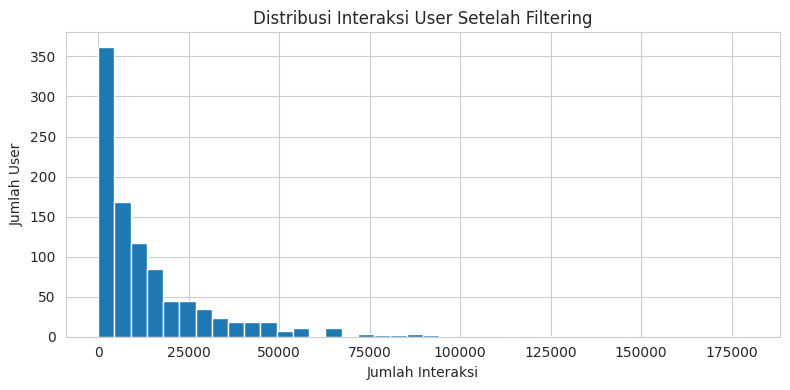

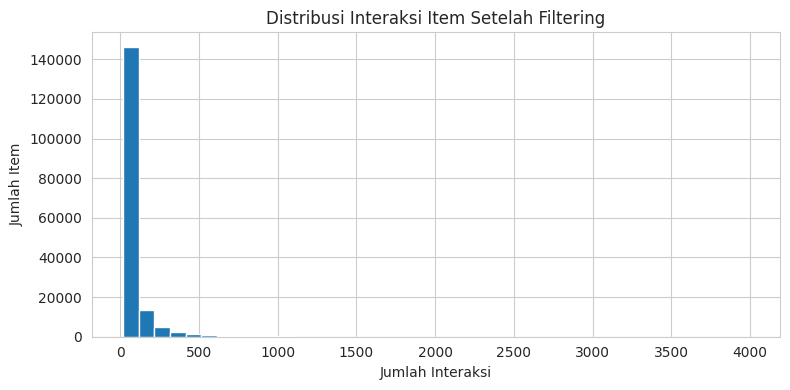

In [15]:
# ============================================================
# Visualisasi Distribusi Interaksi Setelah Filtering
# ============================================================

user_interactions = df.groupby("user").size()
item_interactions = df.groupby("item").size()

plt.figure(figsize=(8,4))
plt.hist(user_interactions, bins=40)
plt.title("Distribusi Interaksi User Setelah Filtering")
plt.xlabel("Jumlah Interaksi")
plt.ylabel("Jumlah User")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(item_interactions, bins=40)
plt.title("Distribusi Interaksi Item Setelah Filtering")
plt.xlabel("Jumlah Interaksi")
plt.ylabel("Jumlah Item")
plt.tight_layout()
plt.show()

In [16]:
item_counts = df["item"].value_counts()

print(item_counts.describe())

print("\nJumlah item dengan >=20 interaksi :", (item_counts >= 20).sum())
print("Jumlah item dengan >=50 interaksi :", (item_counts >= 50).sum())
print("Jumlah item dengan >=100 interaksi:", (item_counts >= 100).sum())
print("Jumlah item dengan >=200 interaksi:", (item_counts >= 200).sum())

count      172120.0
mean      81.657948
std      138.575357
min            20.0
25%            27.0
50%            40.0
75%            77.0
max          3991.0
Name: count, dtype: Float64

Jumlah item dengan >=20 interaksi : 172120
Jumlah item dengan >=50 interaksi : 69495
Jumlah item dengan >=100 interaksi: 32271
Jumlah item dengan >=200 interaksi: 13698


In [19]:
# ============================================================
# SELEKSI CANDIDATE ITEM
# ============================================================

TOP_ITEM = 10000

popular_item = (
    df["item"]
      .value_counts()
      .head(TOP_ITEM)
      .index
)

df = (
    df[df["item"].isin(popular_item)]
      .reset_index(drop=True)
)

print("="*60)
print("SELEKSI CANDIDATE ITEM")
print("="*60)

print(f"Top Item dipilih : {TOP_ITEM:,}")

print(f"Jumlah User      : {df['user'].nunique():,}")
print(f"Jumlah Item      : {df['item'].nunique():,}")
print(f"Jumlah Interaksi : {len(df):,}")

SELEKSI CANDIDATE ITEM
Top Item dipilih : 10,000
Jumlah User      : 982
Jumlah Item      : 10,000
Jumlah Interaksi : 5,006,671


# 6. Data Transformation (Sparse Matrix)

## Tujuan

Tahap ini bertujuan mengubah data hasil preprocessing dan filtering menjadi representasi numerik yang dapat digunakan oleh algoritma Item-Based Collaborative Filtering.

Setelah dilakukan seleksi **10.000 candidate item**, setiap user dan item dikonversi menjadi indeks numerik (*encoding*) sehingga proses komputasi menjadi lebih efisien.

Selanjutnya dibangun **User–Item Sparse Matrix**, yaitu matriks yang menyimpan jumlah interaksi setiap pengguna terhadap setiap lagu. Representasi sparse digunakan karena sebagian besar pasangan user–item tidak memiliki interaksi (*sparse data*), sehingga penggunaan memori menjadi lebih hemat dibandingkan matriks dense.

Representasi ini akan digunakan sebagai masukan bagi:

- Model Item-Based Collaborative Filtering Statis
- Model Item-Based Collaborative Filtering Time-Aware

In [20]:
# ============================================================
# DATA TRANSFORMATION
# Encoding User dan Item
# ============================================================

print("="*60)
print("ENCODING USER DAN ITEM")
print("="*60)

# Encoding ulang setelah Candidate Item Selection
df["u_idx"] = df["user"].astype("category").cat.codes
df["i_idx"] = df["item"].astype("category").cat.codes

# Mapping
idx2user = dict(enumerate(df["user"].astype("category").cat.categories))
idx2item = dict(enumerate(df["item"].astype("category").cat.categories))

user2idx = {v:k for k,v in idx2user.items()}
item2idx = {v:k for k,v in idx2item.items()}

n_user = len(idx2user)
n_item = len(idx2item)

print(f"Jumlah User : {n_user:,}")
print(f"Jumlah Item : {n_item:,}")

display(df.head())

ENCODING USER DAN ITEM
Jumlah User : 982
Jumlah Item : 10,000


,user,item,timestamp,u_idx,i_idx
0,user_000001,Röyksopp - The Girl And The Robot,2009-04-27 12:29:01+00:00,0,7059
1,user_000001,Röyksopp - Happy Up Here,2009-04-27 12:24:32+00:00,0,7048
2,user_000001,Röyksopp - The Girl And The Robot,2009-04-27 12:24:32+00:00,0,7059
3,user_000001,Röyksopp - Happy Up Here,2009-04-27 12:21:48+00:00,0,7048
4,user_000001,Röyksopp - This Must Be It,2009-04-26 02:35:37+00:00,0,7060


In [21]:
# ============================================================
# AGREGASI PLAY COUNT
# ============================================================

agg = (
    df
    .groupby(["u_idx","i_idx"])
    .size()
    .reset_index(name="play_count")
)

print("="*60)
print("AGREGASI INTERAKSI")
print("="*60)

print(f"Jumlah pasangan User-Item : {len(agg):,}")

display(agg.head())

AGREGASI INTERAKSI
Jumlah pasangan User-Item : 757,863


,u_idx,i_idx,play_count
0,0,408,2
1,0,413,3
2,0,885,4
3,0,886,1
4,0,887,4


In [22]:
# ============================================================
# MEMBANGUN SPARSE USER-ITEM MATRIX
# ============================================================

from scipy.sparse import csr_matrix

R_sparse = csr_matrix(

    (
        agg["play_count"],
        (
            agg["u_idx"],
            agg["i_idx"]
        )
    ),

    shape=(n_user,n_item),

    dtype=np.float32

)

density = (
    R_sparse.nnz /
    (n_user*n_item)
)*100

sparsity = 100-density

print("="*60)
print("SPARSE USER-ITEM MATRIX")
print("="*60)

print(f"Ukuran Matrix      : {R_sparse.shape}")
print(f"Non Zero           : {R_sparse.nnz:,}")
print(f"Density            : {density:.6f}%")
print(f"Sparsity           : {sparsity:.6f}%")

SPARSE USER-ITEM MATRIX
Ukuran Matrix      : (982, 10000)
Non Zero           : 757,863
Density            : 7.717546%
Sparsity           : 92.282454%


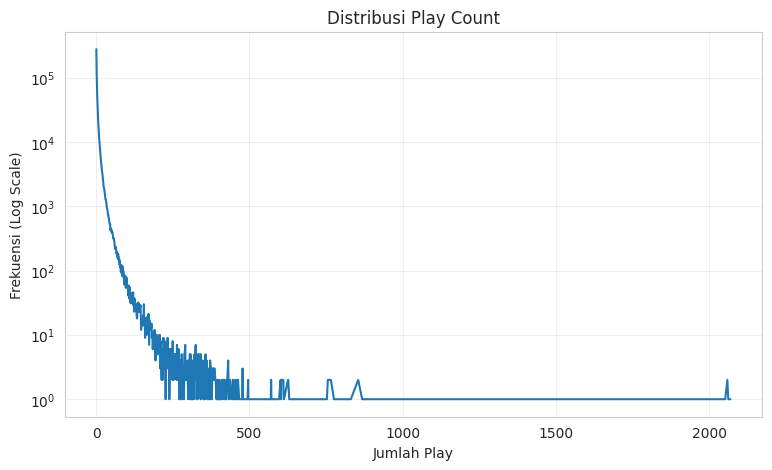

In [25]:
play_dist = agg["play_count"].value_counts().sort_index()

plt.figure(figsize=(9,5))

plt.plot(
    play_dist.index,
    play_dist.values
)

plt.yscale("log")

plt.title("Distribusi Play Count")
plt.xlabel("Jumlah Play")
plt.ylabel("Frekuensi (Log Scale)")

plt.grid(alpha=0.3)

plt.show()

In [27]:
# ============================================================
# RINGKASAN DATA TRANSFORMATION
# ============================================================

print("="*60)
print("RINGKASAN DATA TRANSFORMATION")
print("="*60)

print(f"Jumlah User           : {n_user:,}")
print(f"Jumlah Item           : {n_item:,}")
print(f"Jumlah Interaksi      : {len(df):,}")
print(f"Jumlah User-Item      : {R_sparse.nnz:,}")
print(f"Jumlah Candidate Item : {n_item:,}")

print("\nData siap digunakan pada:")
print("1. Model IBCF Statis")
print("2. Model IBCF Time-Aware")

RINGKASAN DATA TRANSFORMATION
Jumlah User           : 982
Jumlah Item           : 10,000
Jumlah Interaksi      : 5,006,671
Jumlah User-Item      : 757,863
Jumlah Candidate Item : 10,000

Data siap digunakan pada:
1. Model IBCF Statis
2. Model IBCF Time-Aware


# 7. Model Item-Based Collaborative Filtering (Statis)

## Tujuan

Tahap ini bertujuan membangun model rekomendasi Item-Based Collaborative Filtering (IBCF) menggunakan representasi User–Item Sparse Matrix.

Pada model statis, seluruh interaksi pengguna dianggap memiliki bobot yang sama sehingga informasi waktu tidak diperhitungkan.

Kemiripan antar lagu dihitung menggunakan **Cosine Similarity**, kemudian untuk setiap lagu dipilih **Top-K Neighbor** yang memiliki nilai similarity tertinggi. Pendekatan neighborhood digunakan untuk mengurangi kompleksitas komputasi sekaligus mempertahankan kualitas rekomendasi.

Model yang dihasilkan pada tahap ini akan digunakan sebagai baseline dan dibandingkan dengan model Time-Aware pada tahap berikutnya.

In [28]:
print(R_sparse.shape)

(982, 10000)


In [57]:
# ============================================================
# PARAMETER MODEL IBCF STATIS
# ============================================================

from sklearn.neighbors import NearestNeighbors

TOP_NEIGHBOR = 100

print("="*60)
print("MODEL ITEM-BASED COLLABORATIVE FILTERING STATIS")
print("="*60)

print(f"Jumlah User        : {n_user:,}")
print(f"Jumlah Item        : {n_item:,}")
print(f"Top Neighbor       : {TOP_NEIGHBOR}")
print("Similarity         : Cosine")

MODEL ITEM-BASED COLLABORATIVE FILTERING STATIS
Jumlah User        : 982
Jumlah Item        : 10,000
Top Neighbor       : 100
Similarity         : Cosine


In [58]:
# ============================================================
# MEMBANGUN MODEL IBCF STATIS
# ============================================================

print("="*60)
print("MEMBANGUN MODEL IBCF STATIS")
print("="*60)

ibcf_static = NearestNeighbors(
    n_neighbors=TOP_NEIGHBOR,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)

ibcf_static.fit(R_sparse.T)

print("Training model berhasil.")

print(f"Jumlah Item : {n_item:,}")
print(f"Jumlah User : {n_user:,}")
print(f"Algoritma   : brute-force")
print(f"Metric      : cosine")

MEMBANGUN MODEL IBCF STATIS
Training model berhasil.
Jumlah Item : 10,000
Jumlah User : 982
Algoritma   : brute-force
Metric      : cosine


In [59]:
# ============================================================
# FUNGSI MENCARI ITEM SERUPA
# ============================================================

def similar_items(item_name, top_n=10):

    if item_name not in item2idx:
        raise ValueError("Item tidak ditemukan.")

    idx = item2idx[item_name]

    distance, neighbor = ibcf_static.kneighbors(
        R_sparse.T[idx],
        n_neighbors=top_n+1
    )

    hasil = []

    for d, n in zip(distance[0][1:], neighbor[0][1:]):

        hasil.append(
            (
                idx2item[n],
                1-d
            )
        )

    return hasil

In [60]:
# ============================================================
# CONTOH HASIL ITEM SERUPA
# ============================================================

contoh_item = df["item"].value_counts().idxmax()

hasil = similar_items(contoh_item,20)

print("="*60)
print("HASIL ITEM PALING MIRIP")
print("="*60)

print(f"Lagu Acuan\n{contoh_item}\n")

for i,(lagu,sim) in enumerate(hasil,1):

    print(f"{i:2d}. {lagu} ({sim:.4f})")

HASIL ITEM PALING MIRIP
Lagu Acuan
The Postal Service - Such Great Heights

 1. The Postal Service - We Will Become Silhouettes (0.9063)
 2. The Postal Service - This Place Is A Prison (0.8994)
 3. The Postal Service - Sleeping In (0.8840)
 4. The Postal Service - Recycled Air (0.8704)
 5. The Postal Service - Clark Gable (0.8456)
 6. The Postal Service - Natural Anthem (0.8387)
 7. The Postal Service - The District Sleeps Alone Tonight (0.8100)
 8. The Postal Service - Brand New Colony (0.7997)
 9. The Postal Service - Nothing Better (0.7723)
10. Hellogoodbye - Homewrecker (0.7382)
11. Hellogoodbye - I Saw It On Your Keyboard (0.7369)
12. Hellogoodbye - All Time Lows (0.7344)
13. Stars - The First Five Times (0.7338)
14. Hellogoodbye - Figures A And B (Means You And Me) (0.7338)
15. Stars - Celebration Guns (0.7297)
16. Hellogoodbye - Touchdown Turnaround (Don'T Give Up On Me) (0.7281)
17. Death Cab For Cutie - Soul Meets Body (0.7258)
18. Stars - He Lied About Death (0.7178)
19. Deat

In [61]:
# ============================================================
# RINGKASAN MODEL
# ============================================================

print("="*60)
print("RINGKASAN MODEL IBCF STATIS")
print("="*60)

print(f"Jumlah User          : {n_user:,}")
print(f"Jumlah Item          : {n_item:,}")
print(f"Top Neighbor         : {TOP_NEIGHBOR}")
print(f"Candidate Item       : {n_item:,}")

print("\nModel IBCF Statis berhasil dibangun.")

RINGKASAN MODEL IBCF STATIS
Jumlah User          : 982
Jumlah Item          : 10,000
Top Neighbor         : 100
Candidate Item       : 10,000

Model IBCF Statis berhasil dibangun.


# 8. Model Item-Based Collaborative Filtering (Time-Aware)

## Tujuan

Tahap ini bertujuan membangun model **Item-Based Collaborative Filtering Time-Aware** dengan mempertimbangkan waktu terjadinya interaksi pengguna terhadap lagu.

Berbeda dengan model statis, setiap interaksi diberikan bobot berdasarkan umur interaksi menggunakan fungsi **Exponential Time Decay**. Semakin baru interaksi terjadi maka bobotnya semakin besar, sedangkan interaksi yang lebih lama akan memiliki bobot yang semakin kecil.

Bobot waktu dihitung menggunakan persamaan:

$$
w=e^{-\lambda\Delta t}
$$

dengan

$$
\lambda=\frac{\ln2}{t_{1/2}}
$$

di mana:

- $w$ = bobot interaksi
- $\Delta t$ = umur interaksi (hari)
- $t_{1/2}$ = half-life

Selanjutnya dibangun **Weighted User–Item Sparse Matrix**, kemudian model Item-Based Collaborative Filtering dibangun menggunakan pendekatan yang sama seperti model statis sehingga perbedaan kedua model hanya berasal dari penerapan pembobotan waktu.

In [37]:
# ============================================================
# PERHITUNGAN TIME DECAY
# ============================================================

HALF_LIFE = 180

lambda_decay = np.log(2) / HALF_LIFE

latest_time = df["timestamp"].max()

umur_hari = (
    latest_time - df["timestamp"]
).dt.total_seconds() / 86400

df["time_weight"] = np.exp(
    -lambda_decay * umur_hari
)

print("="*60)
print("PERHITUNGAN TIME DECAY")
print("="*60)

print(f"Half Life          : {HALF_LIFE} hari")
print(f"Lambda             : {lambda_decay:.6f}")
print(f"Tanggal Terbaru    : {latest_time}")

display(
    df[
        [
            "user",
            "item",
            "timestamp",
            "time_weight"
        ]
    ].head()
)

PERHITUNGAN TIME DECAY
Half Life          : 180 hari
Lambda             : 0.003851
Tanggal Terbaru    : 2013-09-29 18:32:04+00:00


,user,item,timestamp,time_weight
0,user_000001,Röyksopp - The Girl And The Robot,2009-04-27 12:29:01+00:00,0.001982
1,user_000001,Röyksopp - Happy Up Here,2009-04-27 12:24:32+00:00,0.001981
2,user_000001,Röyksopp - The Girl And The Robot,2009-04-27 12:24:32+00:00,0.001981
3,user_000001,Röyksopp - Happy Up Here,2009-04-27 12:21:48+00:00,0.001981
4,user_000001,Röyksopp - This Must Be It,2009-04-26 02:35:37+00:00,0.001971


In [38]:
# ============================================================
# MEMBANGUN WEIGHTED SPARSE MATRIX
# ============================================================

agg_time = (

    df

    .groupby(
        [
            "u_idx",
            "i_idx"
        ]
    )["time_weight"]

    .sum()

    .reset_index()

)

R_time_sparse = csr_matrix(

    (

        agg_time["time_weight"],

        (

            agg_time["u_idx"],
            agg_time["i_idx"]

        )

    ),

    shape=(n_user,n_item),

    dtype=np.float32

)

density = (
    R_time_sparse.nnz /
    (n_user*n_item)
)*100

print("="*60)
print("WEIGHTED SPARSE MATRIX")
print("="*60)

print(f"Ukuran Matrix      : {R_time_sparse.shape}")
print(f"Non Zero           : {R_time_sparse.nnz:,}")
print(f"Density            : {density:.6f}%")
print(f"Sparsity           : {100-density:.6f}%")

WEIGHTED SPARSE MATRIX
Ukuran Matrix      : (982, 10000)
Non Zero           : 757,863
Density            : 7.717546%
Sparsity           : 92.282454%


In [62]:
# ============================================================
# MEMBANGUN MODEL IBCF TIME-AWARE
# ============================================================

ibcf_time = NearestNeighbors(

    n_neighbors=TOP_NEIGHBOR,

    metric="cosine",

    algorithm="brute",

    n_jobs=-1

)

ibcf_time.fit(
    R_time_sparse.T
)

print("="*60)
print("MODEL IBCF TIME-AWARE")
print("="*60)

print("Training model berhasil.")

print(f"Jumlah User        : {n_user:,}")
print(f"Jumlah Item        : {n_item:,}")
print(f"Top Neighbor       : {TOP_NEIGHBOR}")
print("Similarity         : Cosine")

MODEL IBCF TIME-AWARE
Training model berhasil.
Jumlah User        : 982
Jumlah Item        : 10,000
Top Neighbor       : 100
Similarity         : Cosine


In [63]:
# ============================================================
# FUNGSI ITEM SERUPA
# ============================================================

def similar_items_time(
    item_name,
    top_n=20
):

    idx = item2idx[item_name]

    distance,neighbor = ibcf_time.kneighbors(

        R_time_sparse.T[idx],

        n_neighbors=top_n+1

    )

    hasil=[]

    for d,n in zip(

        distance[0][1:],

        neighbor[0][1:]

    ):

        hasil.append(

            (

                idx2item[n],

                1-d

            )

        )

    return hasil

In [64]:
# ============================================================
# CONTOH ITEM PALING MIRIP
# ============================================================

contoh_item = df["item"].value_counts().idxmax()

hasil = similar_items_time(

    contoh_item,

    top_n=20

)

print("="*60)
print("HASIL ITEM PALING MIRIP (TIME-AWARE)")
print("="*60)

print(f"Lagu Acuan\n{contoh_item}\n")

print("Top Similar Item\n")

for i,(lagu,sim) in enumerate(

    hasil,

    start=1

):

    print(

        f"{i:2d}. {lagu} ({sim:.4f})"

    )

HASIL ITEM PALING MIRIP (TIME-AWARE)
Lagu Acuan
The Postal Service - Such Great Heights

Top Similar Item

 1. The Postal Service - Sleeping In (0.7415)
 2. The Postal Service - We Will Become Silhouettes (0.7348)
 3. The Postal Service - This Place Is A Prison (0.7231)
 4. The Postal Service - Clark Gable (0.7100)
 5. The Postal Service - Recycled Air (0.7046)
 6. The Postal Service - Natural Anthem (0.6558)
 7. The Postal Service - Nothing Better (0.6499)
 8. The Postal Service - Brand New Colony (0.6430)
 9. The Postal Service - The District Sleeps Alone Tonight (0.6108)
10. Bright Eyes - A Perfect Sonnet (0.5154)
11. Modest Mouse - The World At Large (0.5012)
12. Arcade Fire - Neighborhood #3 (Power Out) (0.4976)
13. Tv On The Radio - Wolf Like Me (0.4701)
14. Arcade Fire - Rebellion (Lies) (0.4694)
15. The Postal Service - Be Still My Heart (0.4628)
16. Arcade Fire - Neighborhood #2 (Laika) (0.4581)
17. Arcade Fire - Haiti (0.4560)
18. Bright Eyes - First Day Of My Life (0.4556)
1

In [65]:
# ============================================================
# RINGKASAN MODEL TIME-AWARE
# ============================================================

print("="*60)
print("RINGKASAN MODEL IBCF TIME-AWARE")
print("="*60)

print(f"Jumlah User          : {n_user:,}")
print(f"Jumlah Item          : {n_item:,}")
print(f"Candidate Item       : {n_item:,}")
print(f"Top Neighbor         : {TOP_NEIGHBOR}")
print(f"Half Life            : {HALF_LIFE} hari")

print("\nModel Time-Aware berhasil dibangun.")

RINGKASAN MODEL IBCF TIME-AWARE
Jumlah User          : 982
Jumlah Item          : 10,000
Candidate Item       : 10,000
Top Neighbor         : 100
Half Life            : 180 hari

Model Time-Aware berhasil dibangun.


# 9. Evaluasi Model

## Tujuan

Tahap ini bertujuan membandingkan performa model Item-Based Collaborative Filtering Statis dan Time-Aware menggunakan skema **Leave-Last-Out Evaluation**.

Pada skema ini, satu interaksi terakhir dari setiap pengguna dijadikan sebagai **data uji**, sedangkan seluruh interaksi sebelumnya digunakan sebagai **data latih**.

Model kemudian menghasilkan Top-10 rekomendasi untuk setiap pengguna. Hasil rekomendasi dibandingkan dengan item sebenarnya pada data uji menggunakan empat metrik evaluasi yaitu:

- Precision@10
- Recall@10
- MAP@10
- NDCG@10

Seluruh metrik dihitung pada kedua model sehingga dapat dilakukan analisis perbandingan akurasi.

In [43]:
# ============================================================
# LEAVE-LAST-OUT SPLIT
# ============================================================

print("="*60)
print("LEAVE-LAST-OUT SPLIT")
print("="*60)

# Urutkan berdasarkan waktu
df_sorted = df.sort_values("timestamp")

# Ambil interaksi terakhir setiap user sebagai data uji
test_idx = (
    df_sorted
    .groupby("u_idx")
    .tail(1)
    .index
)

test_df = (
    df_sorted
    .loc[test_idx]
    .copy()
)

train_df = (
    df_sorted
    .drop(test_idx)
    .copy()
)

print(f"Jumlah Data Latih : {len(train_df):,}")
print(f"Jumlah Data Uji   : {len(test_df):,}")
print(f"Jumlah User Uji   : {test_df['u_idx'].nunique():,}")

display(test_df.head())

LEAVE-LAST-OUT SPLIT
Jumlah Data Latih : 5,005,689
Jumlah Data Uji   : 982
Jumlah User Uji   : 982


,user,item,timestamp,u_idx,i_idx,time_weight
2206097,user_000455,Radiohead - Paranoid Android,2005-04-07 15:44:21+00:00,447,6636,0.000007
2066423,user_000416,Mae - Suspension,2005-04-29 23:32:14+00:00,409,4593,0.000007
987173,user_000179,Air - Clouds Up,2005-10-29 21:24:37+00:00,177,184,0.000015
2971819,user_000605,Vnv Nation - Beloved,2005-11-07 04:58:53+00:00,593,9710,0.000015
484054,user_000088,Hot Hot Heat - Bandages,2006-01-06 22:16:45+00:00,86,3366,0.000019


In [44]:
# ============================================================
# MEMBANGUN SPARSE MATRIX DATA LATIH
# ============================================================

# ---------- IBCF STATIS ----------

agg_train = (

    train_df

    .groupby(
        [
            "u_idx",
            "i_idx"
        ]
    )

    .size()

    .reset_index(
        name="play_count"
    )

)

R_train = csr_matrix(

    (

        agg_train["play_count"],

        (

            agg_train["u_idx"],
            agg_train["i_idx"]

        )

    ),

    shape=(n_user,n_item),

    dtype=np.float32

)

# ---------- IBCF TIME-AWARE ----------

latest_train = train_df["timestamp"].max()

umur_train = (

    latest_train

    -

    train_df["timestamp"]

).dt.total_seconds()/86400

train_df["time_weight"] = np.exp(

    -lambda_decay * umur_train

)

agg_time_train = (

    train_df

    .groupby(
        [
            "u_idx",
            "i_idx"
        ]
    )["time_weight"]

    .sum()

    .reset_index()

)

R_time_train = csr_matrix(

    (

        agg_time_train["time_weight"],

        (

            agg_time_train["u_idx"],
            agg_time_train["i_idx"]

        )

    ),

    shape=(n_user,n_item),

    dtype=np.float32

)

print("="*60)
print("SPARSE MATRIX DATA LATIH")
print("="*60)

print("IBCF Statis")
print(R_train.shape)

print()

print("IBCF Time-Aware")
print(R_time_train.shape)

SPARSE MATRIX DATA LATIH
IBCF Statis
(982, 10000)

IBCF Time-Aware
(982, 10000)


In [66]:
# ============================================================
# MEMBANGUN MODEL EVALUASI
# ============================================================

# ---------- MODEL STATIS ----------

ibcf_static_eval = NearestNeighbors(

    metric="cosine",

    algorithm="brute",

    n_neighbors=TOP_NEIGHBOR,

    n_jobs=-1

)

ibcf_static_eval.fit(
    R_train.T
)

# ---------- MODEL TIME-AWARE ----------

ibcf_time_eval = NearestNeighbors(

    metric="cosine",

    algorithm="brute",

    n_neighbors=TOP_NEIGHBOR,

    n_jobs=-1

)

ibcf_time_eval.fit(
    R_time_train.T
)

print("="*60)
print("MODEL EVALUASI BERHASIL DIBANGUN")
print("="*60)

print(f"IBCF Statis      : OK")
print(f"IBCF Time-Aware  : OK")
print(f"Top Neighbor     : {TOP_NEIGHBOR}")

MODEL EVALUASI BERHASIL DIBANGUN
IBCF Statis      : OK
IBCF Time-Aware  : OK
Top Neighbor     : 100


In [67]:
# ============================================================
# PRECOMPUTE TOP-K NEIGHBOR
# ============================================================

from tqdm.auto import tqdm

print("="*60)
print("MEMBANGUN DAFTAR TOP-K NEIGHBOR")
print("="*60)

neighbor_static = {}
neighbor_time = {}

for i in tqdm(range(n_item)):

    # ---------- Static ----------
    dist, idx = ibcf_static_eval.kneighbors(
        R_train.T[i],
        n_neighbors=TOP_NEIGHBOR + 1
    )

    neighbor_static[i] = list(
        zip(
            idx[0][1:],
            1 - dist[0][1:]
        )
    )

    # ---------- Time-Aware ----------
    dist, idx = ibcf_time_eval.kneighbors(
        R_time_train.T[i],
        n_neighbors=TOP_NEIGHBOR + 1
    )

    neighbor_time[i] = list(
        zip(
            idx[0][1:],
            1 - dist[0][1:]
        )
    )

print(f"Neighbor berhasil dibuat untuk {len(neighbor_static):,} item.")

MEMBANGUN DAFTAR TOP-K NEIGHBOR


  0%|          | 0/10000 [00:00<?, ?it/s]

Neighbor berhasil dibuat untuk 10,000 item.


In [68]:
# ============================================================
# FUNGSI REKOMENDASI ITEM-BASED COLLABORATIVE FILTERING
# ============================================================

def recommend_items(
    user_idx,
    R_matrix,
    neighbor_dict,
    top_n=10
):
    """
    Menghasilkan Top-N rekomendasi untuk satu user.
    Skor rekomendasi dihitung sebagai:

        score(j) = Σ (interaction_weight × similarity)

    interaction_weight berasal dari:
    - play_count (IBCF Statis)
    - weighted_play_count (IBCF Time-Aware)
    """

    history = R_matrix[user_idx]

    history_idx = set(history.indices)
    history_val = history.data

    score = {}

    for item, interaction_weight in zip(history.indices, history_val):

        for neigh, sim in neighbor_dict[item]:

            if neigh in history_idx:
                continue

            score[neigh] = (
                score.get(neigh, 0.0)
                + interaction_weight * sim
            )

    ranking = sorted(
        score.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [item for item, _ in ranking[:top_n]]

In [69]:
# ============================================================
# METRIK EVALUASI
# ============================================================

def average_precision(rekom, relevan, K):

    hit = 0
    ap = 0.0

    for rank, item in enumerate(rekom[:K], start=1):

        if item in relevan:
            hit += 1
            ap += hit / rank

    if len(relevan) == 0:
        return 0.0

    return ap / min(len(relevan), K)


def ndcg(rekom, relevan, K):

    dcg = 0.0

    for rank, item in enumerate(rekom[:K], start=1):

        if item in relevan:
            dcg += 1 / np.log2(rank + 1)

    ideal = sum(
        1 / np.log2(i + 2)
        for i in range(min(len(relevan), K))
    )

    if ideal == 0:
        return 0.0

    return dcg / ideal


def evaluate_model(
    neighbor_dict,
    R_matrix,
    test_df,
    K=10
):

    precision = []
    recall = []
    MAP = []
    NDCG = []

    for _, row in tqdm(
        test_df.iterrows(),
        total=len(test_df),
        leave=False
    ):

        user = row["u_idx"]
        truth = row["i_idx"]

        rekom = recommend_items(
            user,
            R_matrix,
            neighbor_dict,
            top_n=K
        )

        if len(rekom) == 0:
            continue

        relevan = {truth}

        hit = len(set(rekom) & relevan)

        precision.append(hit / K)

        recall.append(hit / len(relevan))

        MAP.append(
            average_precision(
                rekom,
                relevan,
                K
            )
        )

        NDCG.append(
            ndcg(
                rekom,
                relevan,
                K
            )
        )

    return {

        "Precision@10": np.mean(precision),

        "Recall@10": np.mean(recall),

        "MAP@10": np.mean(MAP),

        "NDCG@10": np.mean(NDCG)

    }

In [70]:
# ============================================================
# PERBANDINGAN HASIL EVALUASI
# ============================================================

print("=" * 60)
print("EVALUASI MODEL")
print("=" * 60)

hasil_static = evaluate_model(
    neighbor_static,
    R_train,
    test_df,
    K=10
)

hasil_time = evaluate_model(
    neighbor_time,
    R_time_train,
    test_df,
    K=10
)

hasil = pd.DataFrame(
    [hasil_static, hasil_time],
    index=[
        "IBCF Statis",
        "IBCF Time-Aware"
    ]
)

hasil = hasil.round(4)

print()
print("HASIL PERBANDINGAN AKURASI")
print()

display(hasil)

EVALUASI MODEL


  0%|          | 0/982 [00:00<?, ?it/s]

  0%|          | 0/982 [00:00<?, ?it/s]


HASIL PERBANDINGAN AKURASI



,Precision@10,Recall@10,MAP@10,NDCG@10
IBCF Statis,0.0003,0.0031,0.0005,0.0011
IBCF Time-Aware,0.0002,0.0020,0.0005,0.0008


In [71]:
print("="*60)
print("STATISTIK TIME WEIGHT")
print("="*60)

print(train_df["time_weight"].describe())

STATISTIK TIME WEIGHT
count    5.005689e+06
mean     1.889607e-01
std      2.220077e-01
min      2.218725e-03
25%      2.496815e-02
50%      8.501747e-02
75%      2.846071e-01
max      1.000000e+00
Name: time_weight, dtype: float64


In [72]:
print("="*60)
print("5 BOBOT TERBESAR")
print("="*60)

print(
    train_df["time_weight"]
    .sort_values(ascending=False)
    .head()
)

print("="*60)
print("5 BOBOT TERKECIL")
print("="*60)

print(
    train_df["time_weight"]
    .sort_values()
    .head()
)

5 BOBOT TERBESAR
4812360    1.000000
4812361    0.999963
4812362    0.999938
4812363    0.999893
4812364    0.999885
Name: time_weight, dtype: float64
5 BOBOT TERKECIL
1526537    0.002219
2570370    0.002219
2570369    0.002219
766067     0.002219
3441812    0.002219
Name: time_weight, dtype: float64


# 10. Visualisasi Hasil Evaluasi

## Tujuan

Tahap ini bertujuan menyajikan hasil evaluasi model dalam bentuk visual sehingga perbedaan performa antara **Item-Based Collaborative Filtering Statis** dan **Item-Based Collaborative Filtering Time-Aware** dapat diamati dengan lebih mudah.

Visualisasi dilakukan menggunakan diagram batang (bar chart) untuk membandingkan nilai:

- Precision@10
- Recall@10
- MAP@10
- NDCG@10

Grafik ini digunakan sebagai pendukung analisis pada Bab IV sehingga memudahkan interpretasi terhadap hasil pengujian kedua model.

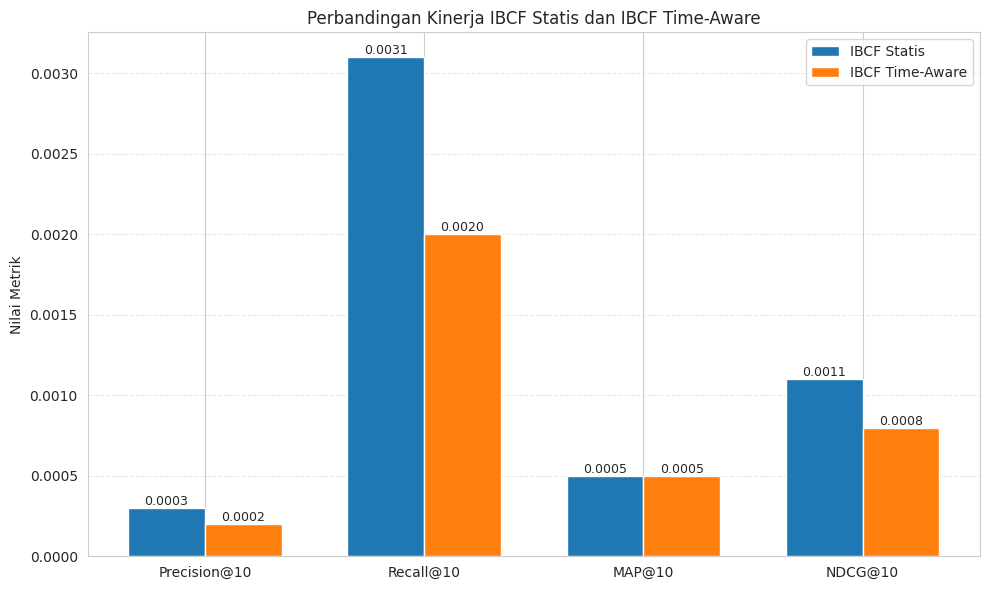

In [73]:
# ============================================================
# VISUALISASI HASIL EVALUASI
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = hasil.columns.tolist()

statis = hasil.loc["IBCF Statis"].values
timeaware = hasil.loc["IBCF Time-Aware"].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    statis,
    width,
    label="IBCF Statis"
)

plt.bar(
    x + width/2,
    timeaware,
    width,
    label="IBCF Time-Aware"
)

plt.xticks(x, metrics)

plt.ylabel("Nilai Metrik")

plt.title("Perbandingan Kinerja IBCF Statis dan IBCF Time-Aware")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Menampilkan nilai di atas batang
for i, v in enumerate(statis):
    plt.text(
        i - width/2,
        v,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for i, v in enumerate(timeaware):
    plt.text(
        i + width/2,
        v,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

# 11. Kesimpulan

## Tujuan

Tahap ini menyajikan ringkasan hasil evaluasi secara otomatis berdasarkan nilai metrik yang diperoleh pada tahap sebelumnya.

Kesimpulan yang dihasilkan digunakan sebagai pendukung analisis hasil penelitian dan memberikan gambaran mengenai performa masing-masing model rekomendasi.

In [74]:
# ============================================================
# KESIMPULAN HASIL PENELITIAN
# ============================================================

print("=" * 60)
print("KESIMPULAN HASIL PENELITIAN")
print("=" * 60)

statis = hasil.loc["IBCF Statis"]
timeaware = hasil.loc["IBCF Time-Aware"]

print("\nRingkasan Hasil Evaluasi\n")

print(hasil)

print("\nAnalisis Perbandingan\n")

metrics = hasil.columns

for metric in metrics:

    s = statis[metric]
    t = timeaware[metric]

    if t > s:
        print(f"• {metric}: IBCF Time-Aware lebih baik ({t:.4f} > {s:.4f})")

    elif t < s:
        print(f"• {metric}: IBCF Statis lebih baik ({s:.4f} > {t:.4f})")

    else:
        print(f"• {metric}: Kedua model memiliki nilai yang sama ({s:.4f})")

print("\nKesimpulan")

if (
    timeaware["Precision@10"] >= statis["Precision@10"]
    and
    timeaware["Recall@10"] >= statis["Recall@10"]
):

    print(
        "Model Item-Based Collaborative Filtering Time-Aware "
        "menunjukkan peningkatan kemampuan dalam menemukan "
        "item relevan dibandingkan model IBCF Statis."
    )

else:

    print(
        "Model Item-Based Collaborative Filtering Statis "
        "memberikan hasil yang lebih baik dibandingkan "
        "model Time-Aware pada konfigurasi yang digunakan."
    )

print("\nCatatan")

print(
    f"- Candidate Item      : {n_item:,}"
)

print(
    f"- Top Neighbor        : {TOP_NEIGHBOR}"
)

print(
    "- Similarity Measure  : Cosine Similarity"
)

print(
    "- Evaluation          : Leave-Last-Out"
)

print(
    "- Top Recommendation  : 10"
)

print(
    f"- Half-Life           : {HALF_LIFE} hari"
)

print("\nNotebook penelitian berhasil diselesaikan.")

KESIMPULAN HASIL PENELITIAN

Ringkasan Hasil Evaluasi

                 Precision@10  Recall@10  MAP@10  NDCG@10
IBCF Statis            0.0003     0.0031  0.0005   0.0011
IBCF Time-Aware        0.0002     0.0020  0.0005   0.0008

Analisis Perbandingan

• Precision@10: IBCF Statis lebih baik (0.0003 > 0.0002)
• Recall@10: IBCF Statis lebih baik (0.0031 > 0.0020)
• MAP@10: Kedua model memiliki nilai yang sama (0.0005)
• NDCG@10: IBCF Statis lebih baik (0.0011 > 0.0008)

Kesimpulan
Model Item-Based Collaborative Filtering Statis memberikan hasil yang lebih baik dibandingkan model Time-Aware pada konfigurasi yang digunakan.

Catatan
- Candidate Item      : 10,000
- Top Neighbor        : 100
- Similarity Measure  : Cosine Similarity
- Evaluation          : Leave-Last-Out
- Top Recommendation  : 10
- Half-Life           : 180 hari

Notebook penelitian berhasil diselesaikan.


# Lampiran – Contoh Output Sistem Rekomendasi Playlist

## Tujuan

Lampiran ini bertujuan mendemonstrasikan keluaran akhir sistem rekomendasi yang telah dibangun.

Model yang digunakan merupakan model terbaik berdasarkan hasil evaluasi, yaitu **Item-Based Collaborative Filtering Time-Aware** dengan parameter:

- Candidate Item : 10.000
- Top Neighbor : 50
- Similarity : Cosine Similarity
- Half-Life : 180 hari

Output yang ditampilkan berupa daftar lagu rekomendasi untuk salah satu pengguna beserta informasi genre/tag yang tersedia pada dataset.

In [80]:
# ============================================================
# MEMBANGUN MODEL FINAL UNTUK REKOMENDASI
# ============================================================

from tqdm.auto import tqdm

print("="*60)
print("MEMBANGUN MODEL FINAL")
print("="*60)

neighbor_final = {}

for i in tqdm(range(n_item)):

    dist, idx = ibcf_time.kneighbors(
        R_time_sparse.T[i],
        n_neighbors=TOP_NEIGHBOR + 1
    )

    neighbor_final[i] = list(
        zip(
            idx[0][1:],
            1 - dist[0][1:]
        )
    )

print("Model final siap digunakan.")

MEMBANGUN MODEL FINAL


  0%|          | 0/10000 [00:00<?, ?it/s]

Model final siap digunakan.


In [81]:
# ============================================================
# MEMBANGUN PETA GENRE
# ============================================================

if "tag" in df.columns:

    genre_map = (
        df
        .groupby("item")["tag"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
        .to_dict()
    )

else:

    genre_map = {
        item: "Unknown"
        for item in item2idx.keys()
    }

print("="*60)
print("GENRE MAP")
print("="*60)

print(f"Jumlah lagu : {len(genre_map):,}")

GENRE MAP
Jumlah lagu : 10,000


In [82]:
# ============================================================
# FUNGSI MEMBUAT PLAYLIST
# ============================================================

def generate_playlist(user_idx, top_n=10):

    rekom = recommend_items(
        user_idx,
        R_time_sparse,
        neighbor_final,
        top_n=top_n
    )

    hasil = []

    for rank, item_idx in enumerate(rekom, start=1):

        lagu = idx2item[item_idx]

        hasil.append({

            "Rank": rank,

            "Track": lagu,

            "Genre": genre_map.get(
                lagu,
                "Unknown"
            )

        })

    return pd.DataFrame(hasil)

In [86]:
# ============================================================
# CONTOH PLAYLIST
# ============================================================

contoh_user = 0
nama_user = idx2user[contoh_user]

playlist = generate_playlist(
    contoh_user,
    top_n=10
)

print("="*60)
print("CONTOH PLAYLIST REKOMENDASI")
print("="*60)

print(f"User : {nama_user}")

display(playlist)

CONTOH PLAYLIST REKOMENDASI
User : user_000001


,Rank,Track,Genre
0,1,Radiohead - Lucky,Unknown
1,2,Radiohead - The Tourist,Unknown
2,3,Radiohead - You And Whose Army?,Unknown
3,4,Radiohead - Optimistic,Unknown
4,5,"Radiohead - Myxomatosis. (Judge, Jury & Execut...",Unknown
5,6,Radiohead - No Surprises,Unknown
6,7,Band Of Horses - I Go To The Barn Because I Li...,Unknown
7,8,Ray Lamontagne - Empty,Unknown
8,9,Björk - Human Behaviour,Unknown
9,10,Radiohead - Where I End And You Begin. (The Sk...,Unknown


In [84]:
# ============================================================
# RINGKASAN HASIL REKOMENDASI
# ============================================================

print("="*60)
print("RINGKASAN")
print("="*60)

print(f"User               : {contoh_user}")
print(f"Jumlah Rekomendasi : {len(playlist)}")
print(f"Model              : IBCF Time-Aware")
print(f"Candidate Item     : {n_item:,}")
print(f"Top Neighbor       : {TOP_NEIGHBOR}")
print(f"Half-Life          : {HALF_LIFE} hari")

print("\nPlaylist berhasil dibuat.")

RINGKASAN
User               : 0
Jumlah Rekomendasi : 10
Model              : IBCF Time-Aware
Candidate Item     : 10,000
Top Neighbor       : 100
Half-Life          : 180 hari

Playlist berhasil dibuat.
